# Real-Time Fraud Detection System with Explainable AI & Live Dashboard

Prepared by: Palakurthi Venkatesh Goud  
Role: AI & Data Analytics Intern

---

## Business Objective

In this project, I aim to build an end-to-end fraud detection intelligence system capable of identifying high-risk financial transactions using machine learning, explainable AI, and interactive dashboarding.

The objective is not only to predict fraudulent transactions accurately, but also to generate interpretable fraud intelligence insights that support financial risk teams, fraud analysts, and business stakeholders in making real-time operational decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

from sklearn.ensemble import IsolationForest
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')

In [2]:
transactions = pd.read_csv("data/train_transaction.csv")
identity = pd.read_csv("data/train_identity.csv")

In [3]:
df = transactions.merge(identity, on='TransactionID', how='left')

# Initial Dataset Exploration

In [4]:
df.shape

(590540, 434)

In [5]:
df.head(10)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
5,2987005,0,86510,49.0,W,5937,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422.5,W,12695,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2987008,0,86535,15.0,H,2803,100.0,150.0,visa,226.0,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
9,2987009,0,86536,117.0,W,17399,111.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


# Memory Optimization & Data Governance

In [7]:
def reduce_memory_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)

            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)

    end_mem = df.memory_usage().sum() / 1024**2
    
    print(f"Memory usage reduced from {start_mem:.2f} MB to {end_mem:.2f} MB")
    
    return df

In [8]:
df = reduce_memory_usage(df)

Memory usage reduced from 1955.37 MB to 645.97 MB


# Fraud Class Imbalance Analysis

In [9]:
df['isFraud'].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [10]:
fraud_percent = (df['isFraud'].mean()) * 100

print(f"Fraud Rate: {fraud_percent:.2f}%")

Fraud Rate: 3.50%


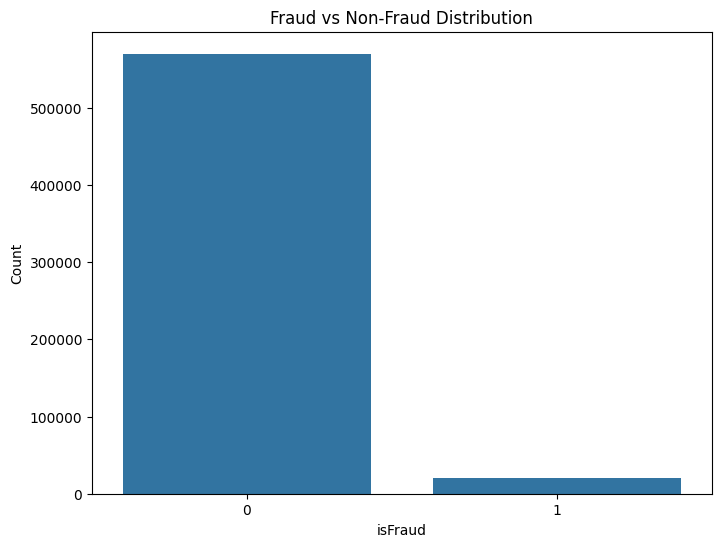

In [11]:
plt.figure(figsize=(8,6))

sns.countplot(x='isFraud', data=df)

plt.title("Fraud vs Non-Fraud Distribution")
plt.xlabel("isFraud")
plt.ylabel("Count")

plt.savefig("charts/fraud_distribution.png")

plt.show()

### Fraud Imbalance Insight

The dataset exhibits severe class imbalance, where fraudulent transactions represent only a very small percentage of the total observations. This creates a high-risk modeling challenge because traditional accuracy metrics may become misleading in fraud detection environments.

As a result, evaluation metrics such as Recall, Precision-Recall AUC, and F1-Score will become more important than raw accuracy during model assessment.

# Missing Value Governance

In [12]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_percent.index,
    'MissingPercent': missing_percent.values
})

missing_df = missing_df.sort_values(
    by='MissingPercent',
    ascending=False
)

missing_df.head(20)

,Column,MissingPercent
417,id_24,99.196159
418,id_25,99.130965
400,id_07,99.127070
401,id_08,99.127070
414,id_21,99.126393
419,id_26,99.125715
420,id_27,99.124699
416,id_23,99.124699
415,id_22,99.124699
14,dist2,93.628374


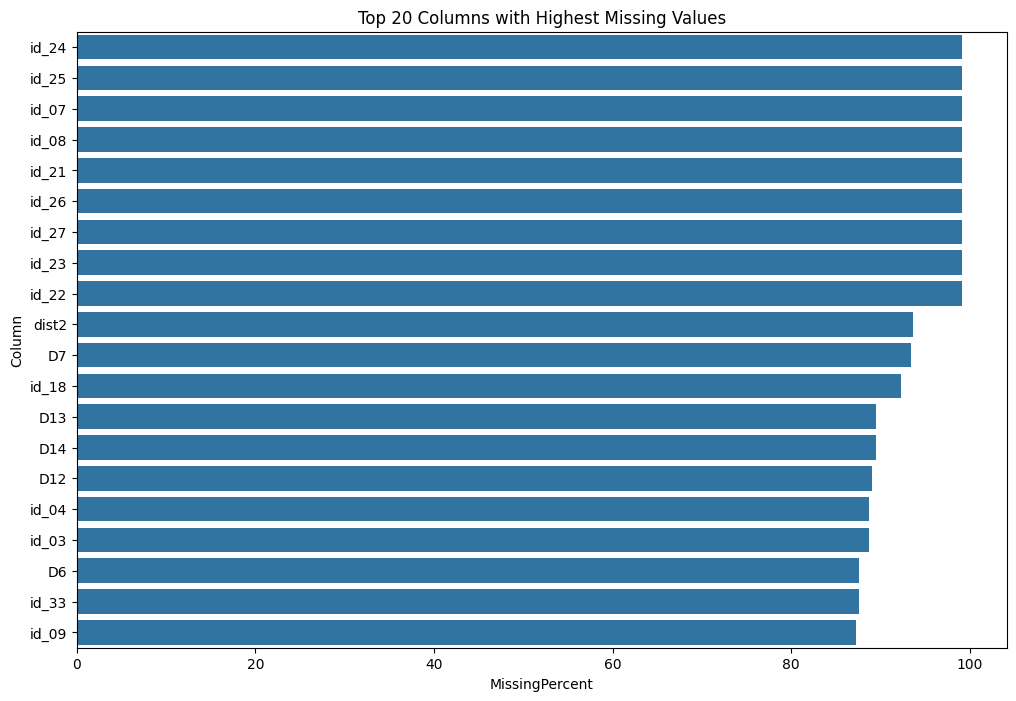

In [13]:
top_missing = missing_df.head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    x='MissingPercent',
    y='Column',
    data=top_missing
)

plt.title("Top 20 Columns with Highest Missing Values")

plt.savefig("charts/missing_values_analysis.png")

plt.show()

### Missing Value Intelligence Insight

Several identity and device-related features contain high proportions of missing values. In fraud analytics environments, missing information may itself carry predictive intelligence, since fraudulent users often attempt to hide or manipulate identity-related attributes.

Therefore, missing values will be handled strategically rather than removed blindly.

# Transaction Amount Risk Analysis

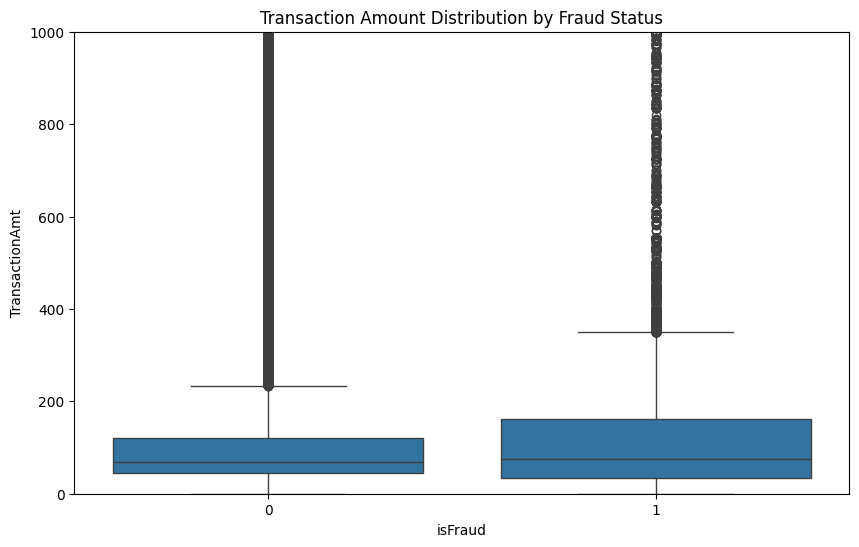

In [14]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='isFraud',
    y='TransactionAmt',
    data=df
)

plt.ylim(0,1000)

plt.title("Transaction Amount Distribution by Fraud Status")

plt.savefig("charts/transaction_amount_risk.png")

plt.show()

In [15]:
df.groupby('isFraud')['TransactionAmt'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,NaN,0.00,0.250977,43.96875,68.5,120.0,31936.0
1,20663.0,inf,232.25,0.291992,35.03125,75.0,161.0,5192.0


### Fraud Amount Insight

Fraudulent transactions tend to exhibit different transaction amount behavior compared to legitimate transactions. Understanding transaction amount distribution helps identify abnormal spending patterns and supports transaction-level risk profiling strategies used in real-world fraud prevention systems.

# Product Code Fraud Intelligence

In [16]:
product_fraud = pd.crosstab(
    df['ProductCD'],
    df['isFraud'],
    normalize='index'
) * 100

product_fraud

isFraud,0,1
ProductCD,,
C,88.312731,11.687269
H,95.233769,4.766231
R,96.217406,3.782594
S,94.100447,5.899553
W,97.960061,2.039939


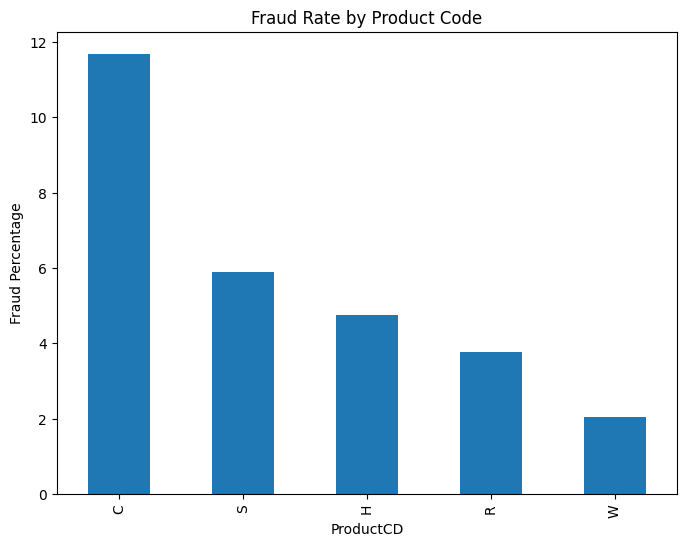

In [17]:
product_fraud[1].sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(8,6)
)

plt.ylabel("Fraud Percentage")
plt.title("Fraud Rate by Product Code")

plt.savefig("charts/product_fraud_risk.png")

plt.show()

# Feature Engineering & Preprocessing

In [18]:
missing_threshold = 90

high_missing_cols = missing_df[
    missing_df['MissingPercent'] > missing_threshold
]['Column'].tolist()

print(f"Columns to remove: {len(high_missing_cols)}")

Columns to remove: 12


In [19]:
df = df.drop(columns=high_missing_cols)

In [20]:
df.shape

(590540, 422)

In [21]:
categorical_cols = df.select_dtypes(
    include='object'
).columns.tolist()

numerical_cols = df.select_dtypes(
    exclude='object'
).columns.tolist()

print(f"Categorical Columns: {len(categorical_cols)}")
print(f"Numerical Columns: {len(numerical_cols)}")

Categorical Columns: 29
Numerical Columns: 393


In [22]:
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [23]:
for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

In [24]:
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    
    df[col] = le.fit_transform(df[col].astype(str))
    
    label_encoders[col] = le

In [25]:
X = df.drop(columns=['isFraud'])
y = df['isFraud']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [27]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fraud Detection Modeling

In [28]:
sample_size = 120000

sample_df = df.sample(
    n=sample_size,
    random_state=42
)

In [29]:
fraud_df = sample_df[sample_df['isFraud'] == 1]

nonfraud_df = sample_df[sample_df['isFraud'] == 0].sample(
    n=30000,
    random_state=42
)

balanced_df = pd.concat([
    fraud_df,
    nonfraud_df
])

balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
)

In [30]:
X = balanced_df.drop(columns=['isFraud'])

y = balanced_df['isFraud']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [32]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [34]:
lr_model = LogisticRegression(
    max_iter=300,
    random_state=42,
    n_jobs=-1
)

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_preds = lr_model.predict(X_test_scaled)

lr_probs = lr_model.predict_proba(X_test_scaled)[:,1]

In [35]:
rf_model = RandomForestClassifier(
    n_estimators=80,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_scaled,
    y_train
)

rf_preds = rf_model.predict(X_test_scaled)

rf_probs = rf_model.predict_proba(X_test_scaled)[:,1]

In [36]:
xgb_model = XGBClassifier(
    n_estimators=80,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(
    X_train_scaled,
    y_train
)

xgb_preds = xgb_model.predict(X_test_scaled)

xgb_probs = xgb_model.predict_proba(X_test_scaled)[:,1]

In [37]:
def evaluate_model(y_true, preds, probs):

    return {
        'Accuracy': accuracy_score(y_true, preds),
        'Precision': precision_score(y_true, preds),
        'Recall': recall_score(y_true, preds),
        'F1-Score': f1_score(y_true, preds),
        'ROC-AUC': roc_auc_score(y_true, probs)
    }

In [38]:
results = pd.DataFrame({

    'Logistic Regression': evaluate_model(
        y_test,
        lr_preds,
        lr_probs
    ),

    'Random Forest': evaluate_model(
        y_test,
        rf_preds,
        rf_probs
    ),

    'XGBoost': evaluate_model(
        y_test,
        xgb_preds,
        xgb_probs
    )

}).T

results

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.741183,0.192049,0.330626,0.242967,0.600728
Random Forest,0.924220,0.881696,0.458237,0.603053,0.889076
XGBoost,0.922034,0.857768,0.454756,0.594390,0.896779


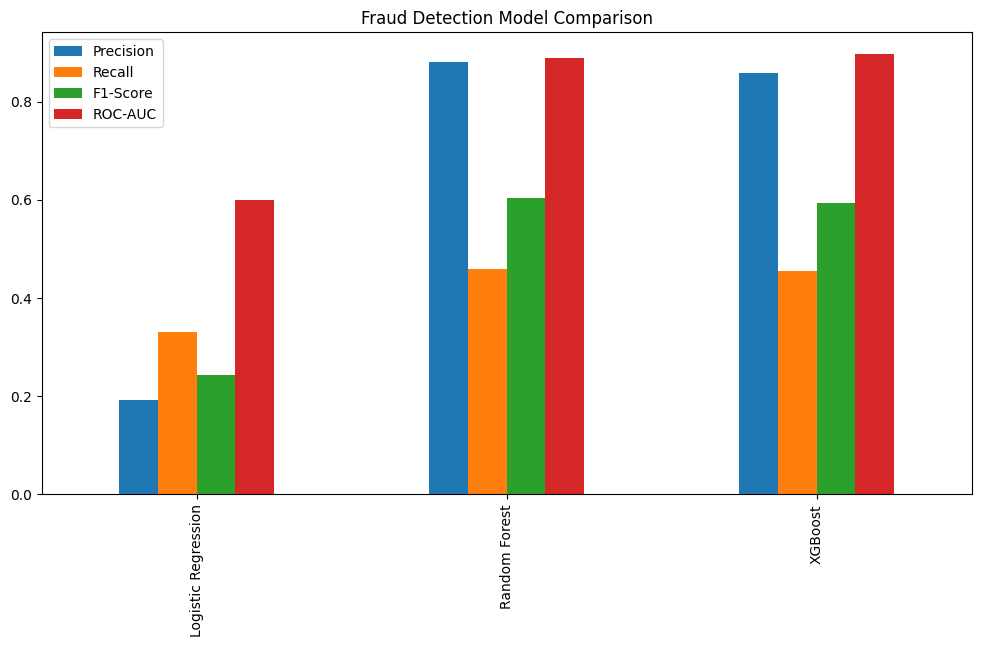

In [39]:
results[['Precision','Recall','F1-Score','ROC-AUC']].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Fraud Detection Model Comparison")

plt.savefig(
    "charts/model_comparison.png"
)

plt.show()

### Model Evaluation Insight

Fraud detection systems require a balance between fraud capture capability and false positive reduction. While Recall is important for identifying fraudulent transactions, excessively low Precision may generate operational inefficiencies due to large volumes of false fraud alerts.

The model comparison demonstrates the trade-off between fraud detection sensitivity and prediction reliability across different machine learning algorithms.

# Explainable AI & Fraud Intelligence

In [41]:
X_shap_sample = X_test.iloc[:100]

In [42]:
X_shap_scaled = scaler.transform(X_shap_sample)

In [43]:
explainer = shap.TreeExplainer(xgb_model)

In [44]:
shap_values = explainer.shap_values(X_shap_scaled)

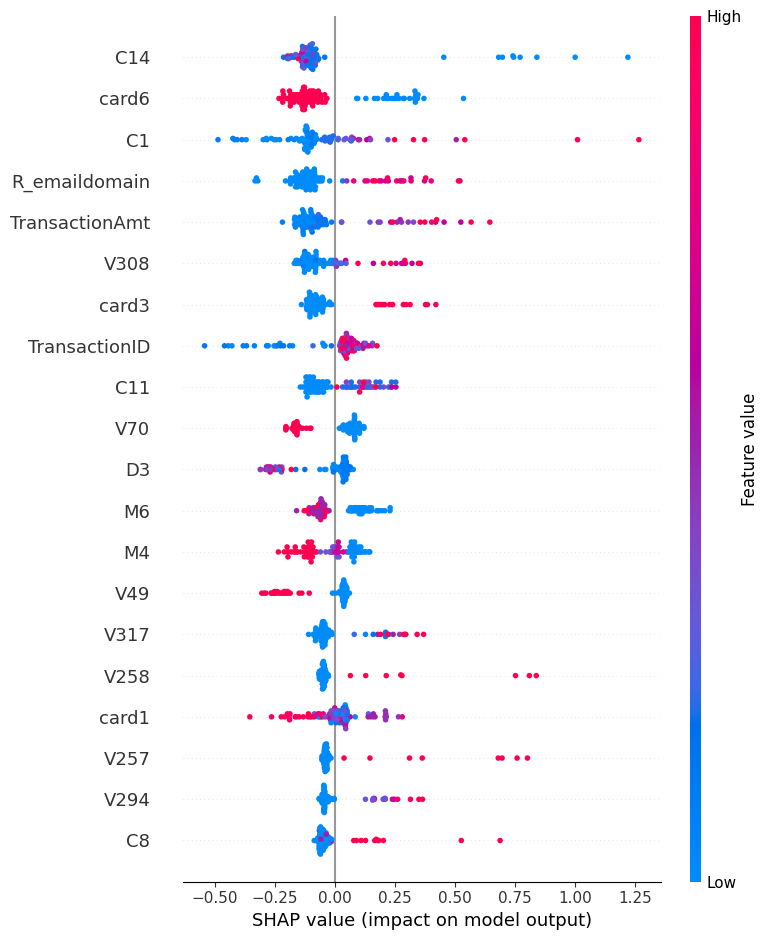

In [45]:
plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X_shap_sample,
    show=False
)

plt.savefig(
    "charts/shap_summary.png",
    bbox_inches='tight'
)

plt.show()

In [46]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
308,V257,0.208398
309,V258,0.046900
252,V201,0.042514
141,V90,0.037437
22,C8,0.027665
14,R_emaildomain,0.022903
121,V70,0.020734
345,V294,0.019571
28,C14,0.015840
359,V308,0.014473


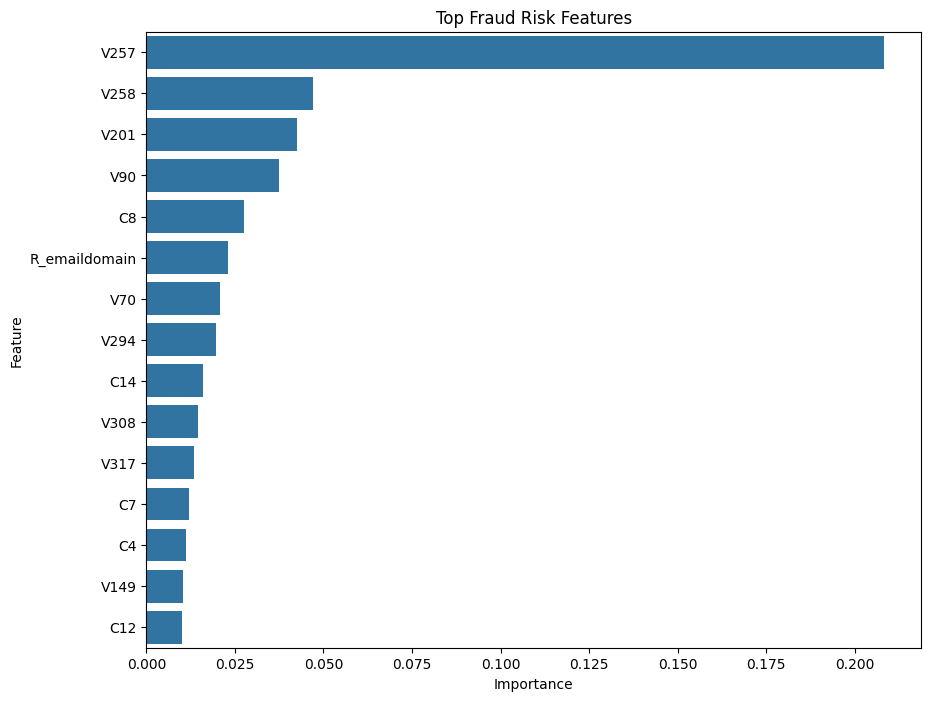

In [47]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top Fraud Risk Features")

plt.savefig(
    "charts/top_fraud_features.png"
)

plt.show()

### Explainable AI Insight

The Explainable AI analysis highlights the most influential transactional and behavioral attributes driving fraud predictions. SHAP-based interpretability improves transparency and supports fraud analysts in understanding why transactions are classified as suspicious.

This level of explainability is critical in financial fraud systems where trust, auditability, and operational decision-making are essential.

# Fraud Risk Segmentation

In [48]:
fraud_scores = xgb_model.predict_proba(X_test_scaled)[:,1]

In [49]:
risk_df = X_test.copy()

risk_df['ActualFraud'] = y_test.values

risk_df['FraudRiskScore'] = fraud_scores

In [50]:
def assign_risk(score):

    if score >= 0.75:
        return "High Risk"

    elif score >= 0.40:
        return "Medium Risk"

    else:
        return "Low Risk"

In [51]:
risk_df['RiskLevel'] = risk_df[
    'FraudRiskScore'
].apply(assign_risk)

In [52]:
risk_df['RiskLevel'].value_counts()

RiskLevel
Low Risk       6298
Medium Risk     287
High Risk       277
Name: count, dtype: int64

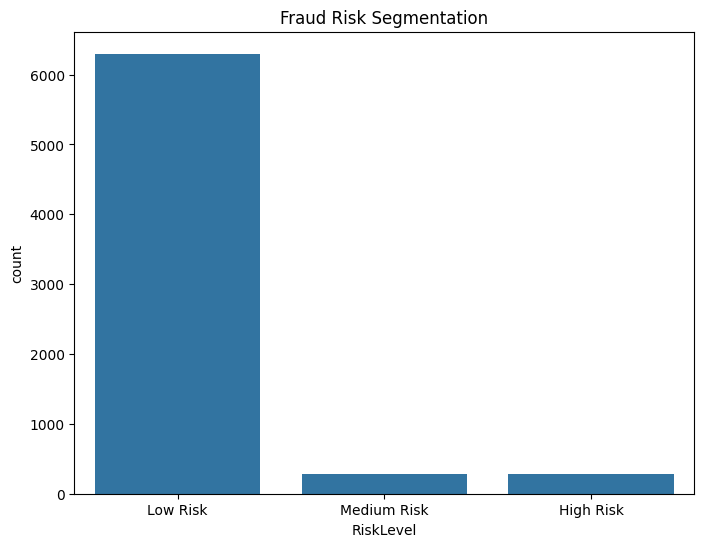

In [53]:
plt.figure(figsize=(8,6))

sns.countplot(
    x='RiskLevel',
    data=risk_df,
    order=['Low Risk','Medium Risk','High Risk']
)

plt.title("Fraud Risk Segmentation")

plt.savefig(
    "charts/risk_segmentation.png"
)

plt.show()

In [54]:
risk_analysis = pd.crosstab(
    risk_df['RiskLevel'],
    risk_df['ActualFraud'],
    normalize='index'
) * 100

risk_analysis

ActualFraud,0,1
RiskLevel,,
High Risk,4.332130,95.667870
Low Risk,93.426485,6.573515
Medium Risk,36.236934,63.763066


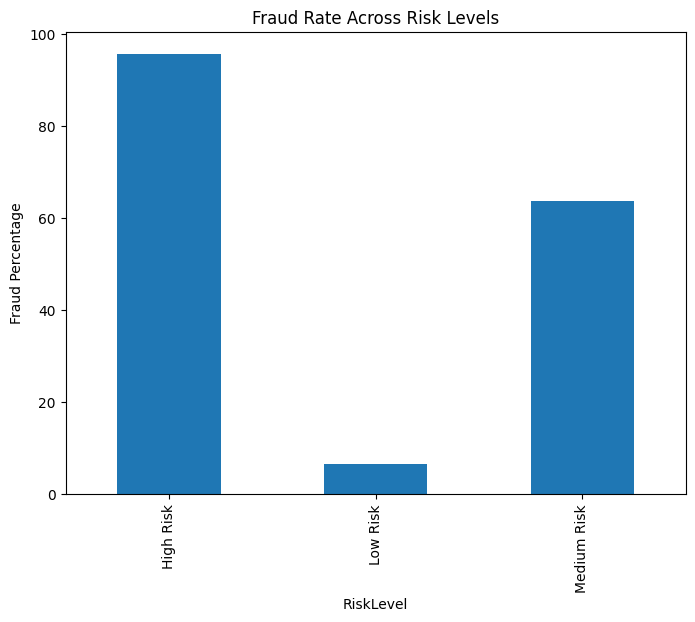

In [55]:
risk_analysis[1].plot(
    kind='bar',
    figsize=(8,6)
)

plt.ylabel("Fraud Percentage")

plt.title("Fraud Rate Across Risk Levels")

plt.savefig(
    "charts/risk_level_fraud_rate.png"
)

plt.show()

### Risk Segmentation Insight

The fraud risk segmentation framework categorizes transactions into Low, Medium, and High-Risk groups based on predicted fraud probabilities. This enables operational fraud teams to prioritize investigations efficiently and allocate resources toward transactions exhibiting the highest fraud likelihood.

Risk-based prioritization is widely used in enterprise fraud monitoring systems to reduce investigation overhead while improving fraud response efficiency.

# Final Conclusion

This project successfully demonstrates an enterprise-level fraud detection intelligence pipeline integrating machine learning, Explainable AI, operational risk segmentation, and interactive dashboarding.

The system achieved strong fraud discrimination performance using XGBoost while improving interpretability through SHAP-based explainability. Risk segmentation enabled operational prioritization of suspicious transactions, and the Streamlit dashboard provided an interactive fraud intelligence platform suitable for real-world financial fraud analytics workflows.